# Run this first !
Ensures correct libraries and imports data

In [9]:
# Run this first !
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")
print(loading.exports(DATA))
print(loading.files(DATA))

# Updated with new data
utt = loading.load(DATA, "all_utterances.csv", "2026-09-30")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-30")
met = loading.load(DATA, "all_metrics.csv", "2026-09-30")

print(utt.shape, sent.shape, met.shape)
sent.head()
data=sent.copy()

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data
['2026-09-13', '2026-09-23', '2026-09-30']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  2570 rows
loaded all_sentences.csv  19092 rows
loaded all_metrics.csv  1021 rows
(2570, 11) (19092, 12) (1021, 6)


# Choose Bank
Amend the commented section to include the bank of choice.

In [10]:
# Create dataframe with bank = 'UBS' (replace with bank of choice)
jpm_financial_data = met[data['bank'] == 'JPM'].copy()
print(jpm_financial_data.shape)
# Drop rows with bank = UBS
jpm_financial_data = jpm_financial_data[jpm_financial_data['bank'] != 'UBS'].copy()
# 35 lines of data per quarter
jpm_financial_data.head(35)

(1021, 6)


/var/folders/c9/gw94qsq971z4r0zg7fh_c7240000gn/T/ipykernel_70047/4211150694.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  jpm_financial_data = met[data['bank'] == 'JPM'].copy()


,bank,quarter,metric_name,value,unit,basis
0,JPM,2022-Q1,average_shares_basic,2977.00,count m,reported
1,JPM,2022-Q1,average_shares_diluted,2981.00,count m,reported
2,JPM,2022-Q1,basic_eps,2.64,USD,reported
3,JPM,2022-Q1,cet1_ratio,11.90,percent,reported
4,JPM,2022-Q1,common_shares,2937.10,count m,reported
5,JPM,2022-Q1,credit_loss_expense,1463.00,USD m,managed
6,JPM,2022-Q1,credit_loss_expense,1463.00,USD m,reported
7,JPM,2022-Q1,diluted_eps,2.63,USD,reported
8,JPM,2022-Q1,dividend_per_share,1.00,USD,reported
9,JPM,2022-Q1,equity_attributable_to_shareholders,253061.00,USD m,reported


In [11]:
jpm_financial_data['bank'].value_counts()

bank
JPM    560
Name: count, dtype: int64

# Total Revenues

In [12]:
# Create a dataframe of total_revenue
jpm_total_revenue_data = jpm_financial_data[jpm_financial_data['metric_name'] == 'total_revenues'].copy()
jpm_total_revenue_data.head()

,bank,quarter,metric_name,value,unit,basis
33,JPM,2022-Q1,total_revenues,31590.0,USD m,managed
34,JPM,2022-Q1,total_revenues,30717.0,USD m,reported
68,JPM,2022-Q2,total_revenues,31630.0,USD m,managed
69,JPM,2022-Q2,total_revenues,30715.0,USD m,reported
103,JPM,2022-Q3,total_revenues,33491.0,USD m,managed


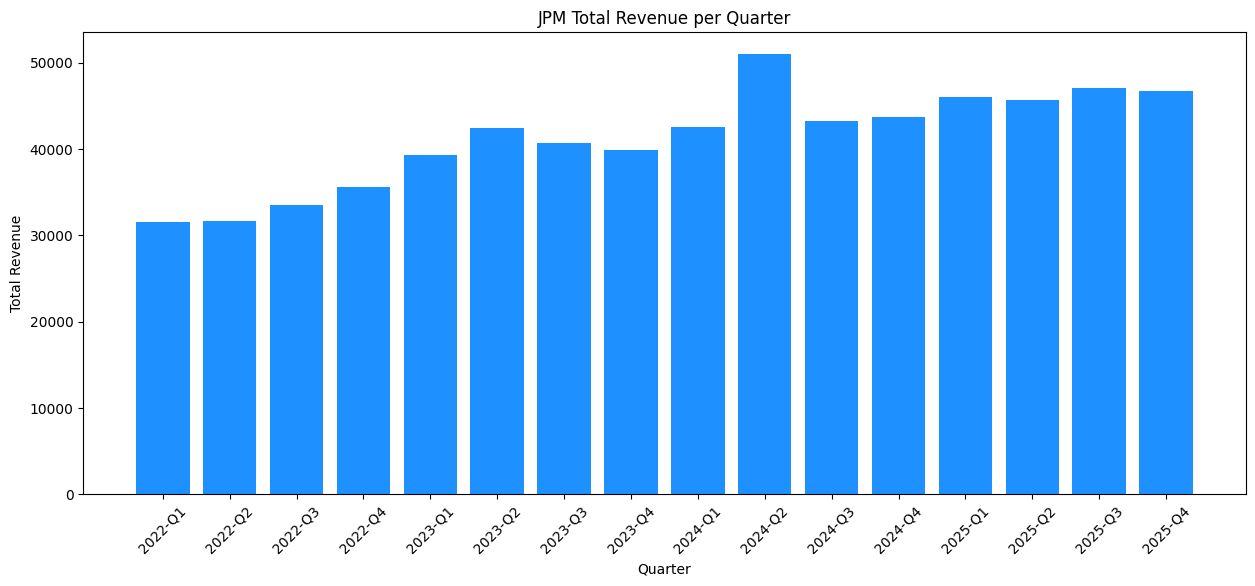

In [19]:
# Plot total_revenue as a bar plot where basis = reported
plt.figure(figsize=(15,6))
plt.bar(jpm_total_revenue_data['quarter'], jpm_total_revenue_data['value'], color='dodgerblue')
# Plot x labels at 45 degrees
plt.xticks(rotation=45)
plt.xlabel('Quarter')
plt.ylabel('Total Revenue')
plt.title('JPM Total Revenue per Quarter')
# Save figure
plt.savefig('JPM_Total_Revenue_per_Quarter.png')
plt.show()

# Net Profit

In [17]:
# Create a dataframe of net_profit where basis = reported
jpm_net_profit_data = jpm_financial_data[(jpm_financial_data['metric_name'] == 'net_profit') & (jpm_financial_data['basis'] == 'reported')].copy()
# Sort in order of quarter
jpm_net_profit_data.sort_values(by='quarter', inplace=True)
jpm_net_profit_data.head(10)

,bank,quarter,metric_name,value,unit,basis
14,JPM,2022-Q1,net_profit,8282.0,USD m,reported
49,JPM,2022-Q2,net_profit,8649.0,USD m,reported
84,JPM,2022-Q3,net_profit,9737.0,USD m,reported
119,JPM,2022-Q4,net_profit,11008.0,USD m,reported
154,JPM,2023-Q1,net_profit,12622.0,USD m,reported
189,JPM,2023-Q2,net_profit,14472.0,USD m,reported
224,JPM,2023-Q3,net_profit,13151.0,USD m,reported
259,JPM,2023-Q4,net_profit,9307.0,USD m,reported
294,JPM,2024-Q1,net_profit,13419.0,USD m,reported
329,JPM,2024-Q2,net_profit,18149.0,USD m,reported


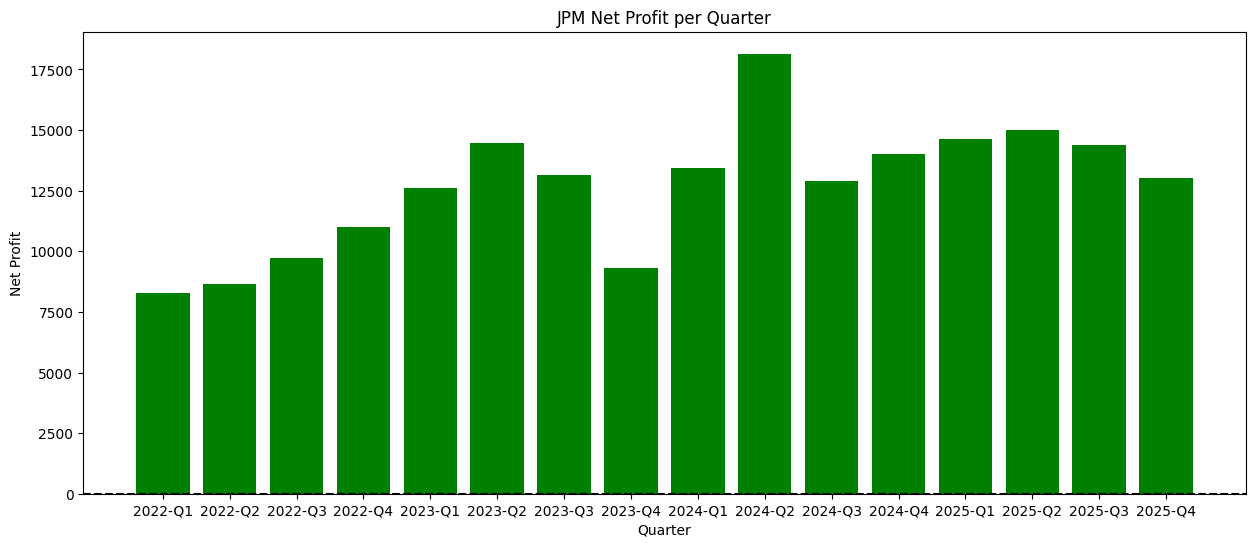

In [ ]:
# Plot net_profit as a bar plot
plt.figure(figsize=(15,6))
plt.bar(jpm_net_profit_data['quarter'], jpm_net_profit_data['value'], color='green')
plt.xlabel('Quarter')
plt.ylabel('Net Profit')

# plot axis line at y = 0 as dashed line
plt.axhline(0, color='black', linestyle='--')
plt.title('JPM Net Profit per Quarter')
# Save figure
plt.savefig('JPM_Net_Profit_per_Quarter.png')
plt.show()